**EDA**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

folder_path = '/content/drive/MyDrive/cookiedong-portfolio'

df = pd.read_csv(f'{folder_path}/order_items_clean.csv')
orders = pd.read_csv(f'{folder_path}/orders_clean.csv')

df['Tanggal Order'] = pd.to_datetime(df['Tanggal Order'])
orders['Tanggal Order'] = pd.to_datetime(orders['Tanggal Order'])

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

Mounted at /content/drive


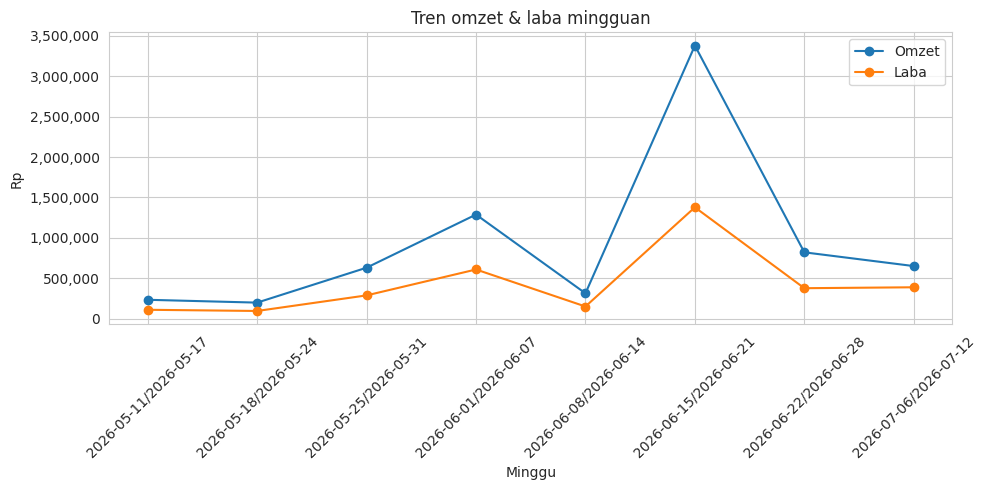

In [ ]:
tren_mingguan = orders.groupby(orders['Tanggal Order'].dt.to_period('W')).agg(
    Total_Omzet=('Total_Omzet', 'sum'),
    Total_Laba=('Total_Laba', 'sum')
).reset_index()
tren_mingguan['Tanggal Order'] = tren_mingguan['Tanggal Order'].astype(str)

plt.figure()
plt.plot(tren_mingguan['Tanggal Order'], tren_mingguan['Total_Omzet'], marker='o', label='Omzet')
plt.plot(tren_mingguan['Tanggal Order'], tren_mingguan['Total_Laba'], marker='o', label='Laba')
plt.title('Tren omzet & laba mingguan')
plt.xlabel('Minggu')
plt.ylabel('Rp')
plt.xticks(rotation=45)
plt.legend()
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

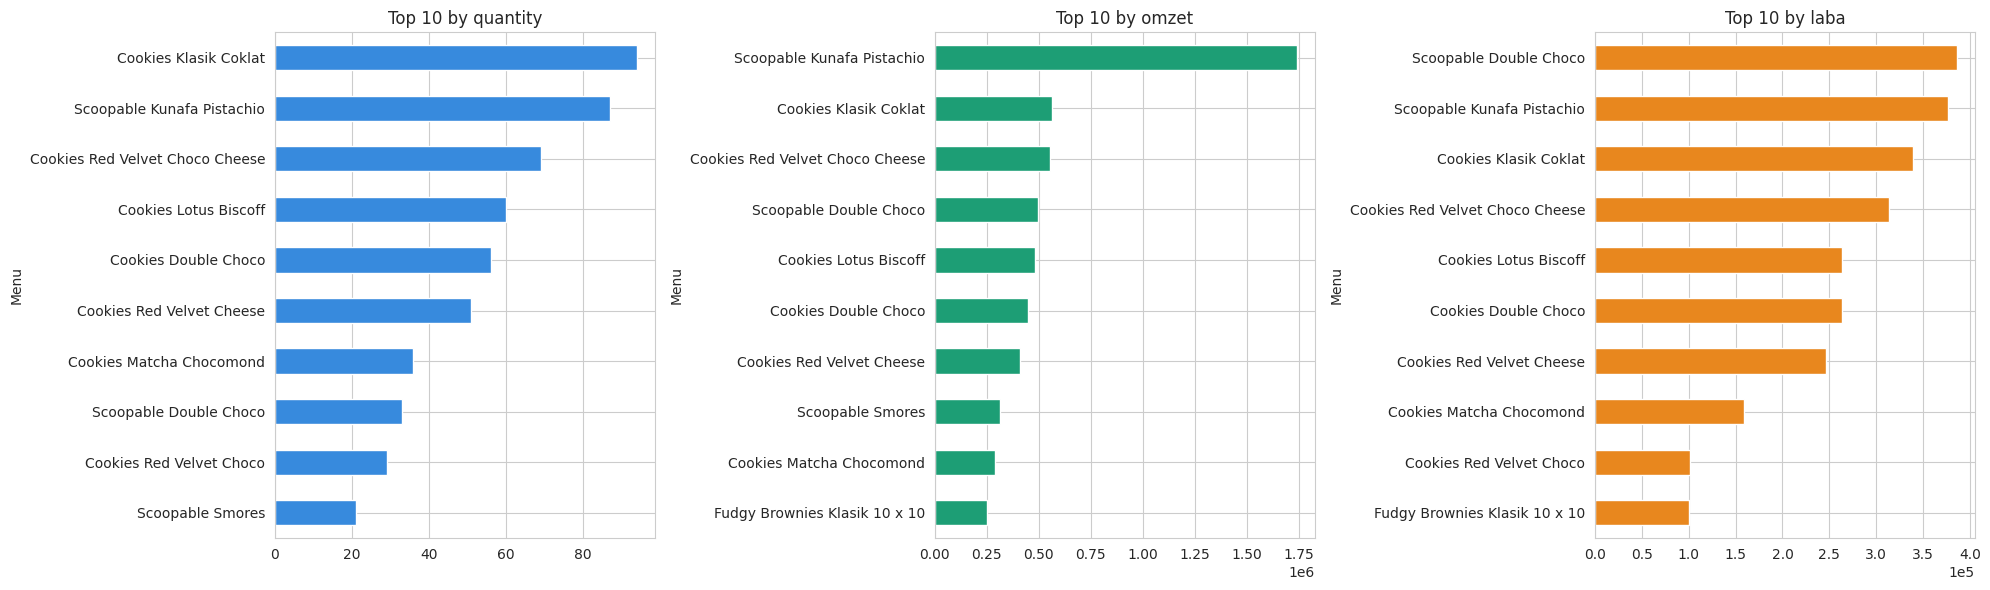

In [ ]:
top_qty = df.groupby('Menu')['Qty'].sum().sort_values(ascending=False).head(10)
top_omzet = df.groupby('Menu')['Subtotal'].sum().sort_values(ascending=False).head(10)
top_laba = df.groupby('Menu')['Laba'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
top_qty.plot(kind='barh', ax=axes[0], color='#378ADD')
axes[0].set_title('Top 10 by quantity')
axes[0].invert_yaxis()

top_omzet.plot(kind='barh', ax=axes[1], color='#1D9E75')
axes[1].set_title('Top 10 by omzet')
axes[1].invert_yaxis()

top_laba.plot(kind='barh', ax=axes[2], color='#E8871E')
axes[2].set_title('Top 10 by laba')
axes[2].invert_yaxis()
axes[2].ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

plt.tight_layout()
plt.show()

In [ ]:
margin_produk = df.groupby('Menu').agg(
    Total_Qty=('Qty', 'sum'),
    Total_Omzet=('Subtotal', 'sum'),
    Total_Laba=('Laba', 'sum')
)
margin_produk['Margin_Persen'] = (margin_produk['Total_Laba'] / margin_produk['Total_Omzet'] * 100).round(1)
margin_produk = margin_produk.sort_values('Margin_Persen', ascending=False)

print("=== Margin tertinggi ===")
print(margin_produk.head(5))
print("\n=== Margin terendah ===")
print(margin_produk.tail(5))

=== Margin tertinggi ===
                           Total_Qty  Total_Omzet  Total_Laba  Margin_Persen
Menu                                                                        
Scoopable Double Choco            33     495000.0   386030.70           78.0
Cookies Red Velvet Cheese         51     408000.0   246033.69           60.3
Cookies Klasik Coklat             94     564000.0   339261.04           60.2
Cookies Double Choco              56     448000.0   263082.40           58.7
Cookies Red Velvet Choco          29     174000.0   101363.99           58.3

=== Margin terendah ===
                            Total_Qty  Total_Omzet  Total_Laba  Margin_Persen
Menu                                                                         
Scoopable Choco Cheesy             15     225000.0     79830.0           35.5
Scoopable Martabak                  1      15000.0      5193.0           34.6
Scoopable Choco Crumbs              9     135000.0     43155.0           32.0
Scoopable Smores     

In [ ]:
kategori_summary = df.groupby('Kategori Menu').agg(
    Total_Qty=('Qty', 'sum'),
    Total_Omzet=('Subtotal', 'sum'),
    Total_Laba=('Laba', 'sum')
)
kategori_summary['Margin_Persen'] = (kategori_summary['Total_Laba'] / kategori_summary['Total_Omzet'] * 100).round(1)
kategori_summary = kategori_summary.sort_values('Total_Laba', ascending=False)

print(kategori_summary)

                Total_Qty  Total_Omzet  Total_Laba  Margin_Persen
Kategori Menu                                                    
Cookies               430    3154000.0  1820949.18           57.7
Scoopable             166    2925000.0   990038.70           33.8
Fudgy Brownies         38    1229000.0   507175.52           41.3
Banana Bread            8     208000.0    80042.63           38.5


In [ ]:
channel_summary = orders.groupby('Channel').agg(
    Jumlah_Order=('Order_ID', 'count'),
    Total_Omzet=('Total_Omzet', 'sum'),
    Total_Laba=('Total_Laba', 'sum'),
    AOV=('Total_Omzet', 'mean')
).round(0)
channel_summary['Margin_Persen'] = (channel_summary['Total_Laba'] / channel_summary['Total_Omzet'] * 100).round(1)

print(channel_summary)

           Jumlah_Order  Total_Omzet  Total_Laba       AOV  Margin_Persen
Channel                                                                  
Instagram             4    1745000.0    731086.0  436250.0           41.9
Whatsapp             32    5771000.0   2667120.0  180344.0           46.2


In [ ]:
top_customer = orders.groupby('Customer').agg(
    Jumlah_Order=('Order_ID', 'count'),
    Total_Omzet=('Total_Omzet', 'sum'),
    Total_Laba=('Total_Laba', 'sum')
).sort_values('Total_Laba', ascending=False).head(10)

print(top_customer)

              Jumlah_Order  Total_Omzet  Total_Laba
Customer                                           
Dewi Lestari             3    2241000.0  1010771.06
Syifa                    2    1474000.0   586838.40
Bella Khanza             3    1075000.0   377145.80
Dara Ariska              1     396000.0   227020.02
Nabila                   1     203000.0   138984.30
Fara Diba                3     285000.0   130653.66
Ana Kusuma               1     210000.0   126320.60
Aini                     1     201000.0   103780.65
Wida Warnita             1     162000.0    93739.08
Dafina                   1     160000.0    90310.60


In [ ]:
order_per_customer = orders.groupby('Customer')['Order_ID'].count()
repeat = (order_per_customer > 1).sum()
one_time = (order_per_customer == 1).sum()

omzet_repeat = orders[orders['Customer'].isin(order_per_customer[order_per_customer > 1].index)]['Total_Omzet'].sum()
laba_repeat = orders[orders['Customer'].isin(order_per_customer[order_per_customer > 1].index)]['Total_Laba'].sum()
omzet_total = orders['Total_Omzet'].sum()
laba_total = orders['Total_Laba'].sum()

print(f"Repeat customer: {repeat}, One-time customer: {one_time}")
print(f"Kontribusi omzet dari repeat customer: {omzet_repeat/omzet_total*100:.1f}%")
print(f"Kontribusi laba dari repeat customer: {laba_repeat/laba_total*100:.1f}%")

Repeat customer: 4, One-time customer: 25
Kontribusi omzet dari repeat customer: 67.5%
Kontribusi laba dari repeat customer: 62.0%


**CUSTOMER SEGMENTATION**

In [ ]:
tanggal_referensi = orders['Tanggal Order'].max() + pd.Timedelta(days=1)

rfm = orders.groupby('Customer').agg(
    Recency=('Tanggal Order', lambda x: (tanggal_referensi - x.max()).days),
    Frequency=('Order_ID', 'count'),
    Monetary=('Total_Omzet', 'sum'),
    Total_Laba=('Total_Laba', 'sum')
).reset_index()

rfm['Margin_Persen'] = (rfm['Total_Laba'] / rfm['Monetary'] * 100).round(1)

rfm.sort_values('Monetary', ascending=False)

,Customer,Recency,Frequency,Monetary,Total_Laba,Margin_Persen
12,Dewi Lestari,27,3,2241000.0,1010771.06,45.1
24,Syifa,24,2,1474000.0,586838.40,39.8
8,Bella Khanza,21,3,1075000.0,377145.80,35.1
10,Dara Ariska,2,1,396000.0,227020.02,57.3
13,Fara Diba,18,3,285000.0,130653.66,45.8
5,Ana Kusuma,38,1,210000.0,126320.60,60.2
20,Nabila,1,1,203000.0,138984.30,68.5
2,Aini,30,1,201000.0,103780.65,51.6
26,Umay,16,1,164000.0,71899.87,43.8
27,Wida Warnita,48,1,162000.0,93739.08,57.9


In [ ]:
def skor_recency(hari):
    if hari <= 14: return 4
    elif hari <= 30: return 3
    elif hari <= 45: return 2
    else: return 1

def skor_frequency(freq):
    if freq >= 3: return 4
    elif freq == 2: return 3
    else: return 1

def skor_monetary(omzet):
    if omzet >= 1000000: return 4
    elif omzet >= 400000: return 3
    elif omzet >= 150000: return 2
    else: return 1

rfm['R_Score'] = rfm['Recency'].apply(skor_recency)
rfm['F_Score'] = rfm['Frequency'].apply(skor_frequency)
rfm['M_Score'] = rfm['Monetary'].apply(skor_monetary)
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

rfm.sort_values('RFM_Score', ascending=False)

,Customer,Recency,Frequency,Monetary,Total_Laba,Margin_Persen,R_Score,F_Score,M_Score,RFM_Score
8,Bella Khanza,21,3,1075000.0,377145.80,35.1,3,4,4,11
12,Dewi Lestari,27,3,2241000.0,1010771.06,45.1,3,4,4,11
24,Syifa,24,2,1474000.0,586838.40,39.8,3,3,4,10
13,Fara Diba,18,3,285000.0,130653.66,45.8,3,4,2,9
10,Dara Ariska,2,1,396000.0,227020.02,57.3,4,1,2,7
20,Nabila,1,1,203000.0,138984.30,68.5,4,1,2,7
9,Dafina,20,1,160000.0,90310.60,56.4,3,1,2,6
7,Banyu Gendis,1,1,52000.0,22727.11,43.7,4,1,1,6
2,Aini,30,1,201000.0,103780.65,51.6,3,1,2,6
26,Umay,16,1,164000.0,71899.87,43.8,3,1,2,6


In [ ]:
def segmentasi(row):
    if row['RFM_Score'] >= 10:
        return 'Champion'
    elif row['F_Score'] >= 3 and row['M_Score'] >= 2:
        return 'Loyal Customer'
    elif row['Frequency'] == 1 and row['M_Score'] >= 3:
        return 'New High-Value'
    elif row['Frequency'] == 1 and row['R_Score'] >= 3:
        return 'New/Recent Customer'
    elif row['R_Score'] <= 2:
        return 'At Risk/Lapsed'
    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(segmentasi, axis=1)

print(rfm['Segment'].value_counts())
rfm.sort_values('RFM_Score', ascending=False)

Segment
New/Recent Customer    17
At Risk/Lapsed          8
Champion                3
Loyal Customer          1
Name: count, dtype: int64


,Customer,Recency,Frequency,Monetary,Total_Laba,Margin_Persen,R_Score,F_Score,M_Score,RFM_Score,Segment
8,Bella Khanza,21,3,1075000.0,377145.80,35.1,3,4,4,11,Champion
12,Dewi Lestari,27,3,2241000.0,1010771.06,45.1,3,4,4,11,Champion
24,Syifa,24,2,1474000.0,586838.40,39.8,3,3,4,10,Champion
13,Fara Diba,18,3,285000.0,130653.66,45.8,3,4,2,9,Loyal Customer
10,Dara Ariska,2,1,396000.0,227020.02,57.3,4,1,2,7,New/Recent Customer
20,Nabila,1,1,203000.0,138984.30,68.5,4,1,2,7,New/Recent Customer
9,Dafina,20,1,160000.0,90310.60,56.4,3,1,2,6,New/Recent Customer
7,Banyu Gendis,1,1,52000.0,22727.11,43.7,4,1,1,6,New/Recent Customer
2,Aini,30,1,201000.0,103780.65,51.6,3,1,2,6,New/Recent Customer
26,Umay,16,1,164000.0,71899.87,43.8,3,1,2,6,New/Recent Customer


In [ ]:
print("=== Top 5 by Monetary (Omzet) ===")
print(rfm.nlargest(5, 'Monetary')[['Customer', 'Monetary', 'Total_Laba', 'Margin_Persen']])

print("\n=== Top 5 by Total_Laba ===")
print(rfm.nlargest(5, 'Total_Laba')[['Customer', 'Monetary', 'Total_Laba', 'Margin_Persen']])

=== Top 5 by Monetary (Omzet) ===
        Customer   Monetary  Total_Laba  Margin_Persen
12  Dewi Lestari  2241000.0  1010771.06           45.1
24         Syifa  1474000.0   586838.40           39.8
8   Bella Khanza  1075000.0   377145.80           35.1
10   Dara Ariska   396000.0   227020.02           57.3
13     Fara Diba   285000.0   130653.66           45.8

=== Top 5 by Total_Laba ===
        Customer   Monetary  Total_Laba  Margin_Persen
12  Dewi Lestari  2241000.0  1010771.06           45.1
24         Syifa  1474000.0   586838.40           39.8
8   Bella Khanza  1075000.0   377145.80           35.1
10   Dara Ariska   396000.0   227020.02           57.3
20        Nabila   203000.0   138984.30           68.5


In [ ]:
rfm.to_csv(f'{folder_path}/rfm_customer.csv', index=False)
print("rfm_customer.csv berhasil disimpan")

rfm_customer.csv berhasil disimpan


In [ ]:
import pandas as pd

folder_path = '/content/drive/MyDrive/cookiedong-portfolio'

# ======================================================
# 1. order_items_clean.csv — bulatkan ke integer
# ======================================================
df = pd.read_csv(f'{folder_path}/order_items_clean.csv')

kolom_items = ['Harga', 'Subtotal', 'HPP', 'Total_HPP', 'Laba']
for kolom in kolom_items:
    df[kolom] = pd.to_numeric(df[kolom], errors='coerce').round(0).astype('Int64')

# Margin_Persen tetap dibiarkan desimal (karena ini persentase, bukan nominal Rupiah)
df['Margin_Persen'] = pd.to_numeric(df['Margin_Persen'], errors='coerce').round(2)

df.to_csv(f'{folder_path}/order_items_clean.csv', index=False)
print("order_items_clean.csv sudah dibulatkan ke angka bulat")
print(df[kolom_items + ['Margin_Persen']].head())

# ======================================================
# 2. orders_clean.csv — bulatkan ke integer
# ======================================================
orders = pd.read_csv(f'{folder_path}/orders_clean.csv')

kolom_orders = ['Total_Omzet', 'Total_HPP', 'Total_Laba']
for kolom in kolom_orders:
    orders[kolom] = pd.to_numeric(orders[kolom], errors='coerce').round(0).astype('Int64')

orders['Margin_Persen'] = pd.to_numeric(orders['Margin_Persen'], errors='coerce').round(2)

orders.to_csv(f'{folder_path}/orders_clean.csv', index=False)
print("\norders_clean.csv sudah dibulatkan ke angka bulat")
print(orders[kolom_orders + ['Margin_Persen']].head())

# ======================================================
# 3. rfm_customer.csv — bulatkan ke integer
# ======================================================
rfm = pd.read_csv(f'{folder_path}/rfm_customer.csv')

kolom_rfm = ['Monetary', 'Total_Laba']
for kolom in kolom_rfm:
    rfm[kolom] = pd.to_numeric(rfm[kolom], errors='coerce').round(0).astype('Int64')

rfm['Margin_Persen'] = pd.to_numeric(rfm['Margin_Persen'], errors='coerce').round(2)

rfm.to_csv(f'{folder_path}/rfm_customer.csv', index=False)
print("\nrfm_customer.csv sudah dibulatkan ke angka bulat")
print(rfm[kolom_rfm + ['Margin_Persen']].head())

order_items_clean.csv sudah dibulatkan ke angka bulat
   Harga  Subtotal    HPP  Total_HPP   Laba  Margin_Persen
0   6000     18000   2633       7900  10100          56.11
1  20000     40000  15670      31340   8660          21.65
2   8000      8000   3521       3521   4479          55.99
3  15000     15000  10280      10280   4720          31.47
4  15000     45000   3302       9906  35094          77.99

orders_clean.csv sudah dibulatkan ke angka bulat
   Total_Omzet  Total_HPP  Total_Laba  Margin_Persen
0        27000      15580       11420          42.30
1        70000      29533       40467          57.81
2       201000      97219      103781          51.63
3        81000      51118       29882          36.89
4        16000       6478        9522          59.51

rfm_customer.csv sudah dibulatkan ke angka bulat
   Monetary  Total_Laba  Margin_Persen
0     27000       11420           42.3
1     70000       40467           57.8
2    201000      103781           51.6
3     81000       